In [7]:
# Notebook 2: 02_embedding_retrieval.ipynb

# Cell 1: Install required packages (run once)
!pip install sentence-transformers numpy scikit-learn pandas

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

In [20]:
# Cell 2: Load knowledge base from Notebook 1 (dynamic, production-style)
import json

# Load the knowledge base that was created in Notebook 1
with open('knowledge_base.json', 'r') as f:
    kb_data = json.load(f)
    kb_texts = [article['content'] for article in kb_data]
    kb_titles = [article['title'] for article in kb_data]
    kb_doc_ids = [article['doc_id'] for article in kb_data]
    kb_tags = [article['tags'] for article in kb_data]
    kb_languages = [article['language'] for article in kb_data]

print(f"✅ Loaded {len(kb_texts)} knowledge articles from Notebook 1")
print(f"\n📚 Knowledge base summary:")
print(f"   - Total documents: {len(kb_texts)}")
print(f"   - Languages: {set(kb_languages)}")
print(f"   - Topics: TikTok, CapCut, Lark, Privacy")

print(f"\n📄 Sample document:")
print(f"   Title: {kb_titles[0]}")
print(f"   Content: {kb_texts[0][:150]}...")
print(f"   Tags: {kb_tags[0]}")
print(f"   Language: {kb_languages[0]}")

# Optional: Display all document titles for visibility
print(f"\n📑 Available knowledge articles:")
for i, title in enumerate(kb_titles, 1):
    print(f"   {i}. {title} ({kb_languages[i-1]})")

✅ Loaded 7 knowledge articles from Notebook 1

📚 Knowledge base summary:
   - Total documents: 7
   - Languages: {'id', 'ms', 'en'}
   - Topics: TikTok, CapCut, Lark, Privacy

📄 Sample document:
   Title: TikTok Algorithm Guide 2025
   Content: The TikTok algorithm prioritizes watch time (60%), completion rate (25%), and engagement (15%). For best results, post when your audience is active (7...
   Tags: ['tiktok', 'algorithm', 'growth']
   Language: en

📑 Available knowledge articles:
   1. TikTok Algorithm Guide 2025 (en)
   2. Shadowban Resolution Process (en)
   3. CapCut Login Troubleshooting (en)
   4. Panduan Pengguna TikTok Indonesia (id)
   5. Panduan CapCut Bahasa Melayu (ms)
   6. Lark Administration Guide (en)
   7. Data Privacy at ByteDance (en)


In [21]:
# Cell 3: Load embedding model
print("🔄 Loading sentence transformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"✅ Model loaded: {model.get_sentence_embedding_dimension()} dimensions")
print(f"   Model max sequence length: {model.max_seq_length} tokens")

🔄 Loading sentence transformer model...
✅ Model loaded: 384 dimensions
   Model max sequence length: 256 tokens


In [22]:
# Cell 4: Create embeddings for entire knowledge base
print("🔄 Creating embeddings for knowledge base...")
kb_embeddings = model.encode(kb_texts, show_progress_bar=True)
print(f"✅ Embeddings created: {kb_embeddings.shape}")
print(f"   Shape: {kb_embeddings.shape[0]} documents × {kb_embeddings.shape[1]} dimensions")

🔄 Creating embeddings for knowledge base...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Embeddings created: (7, 384)
   Shape: 7 documents × 384 dimensions


In [11]:
# Cell 5: Define retrieval function with cosine similarity

def retrieve(query, k=3):
    """
    Retrieve top-k most relevant documents for a query
    
    Parameters:
    - query: string, user's question
    - k: int, number of documents to retrieve
    
    Returns:
    - List of top-k relevant documents
    - List of corresponding similarity scores
    """
    # Encode the query
    q_emb = model.encode([query])
    
    # Calculate cosine similarities between query and all knowledge base documents
    similarities = cosine_similarity(q_emb, kb_embeddings)[0]
    
    # Get top-k indices (highest similarity scores)
    top_indices = np.argsort(similarities)[-k:][::-1]
    
    # Retrieve documents and scores
    top_docs = [kb_texts[i] for i in top_indices]
    top_scores = [similarities[i] for i in top_indices]
    
    return top_docs, top_scores

# Test the retrieval function
test_query = "How do I fix shadowban on TikTok?"
docs, scores = retrieve(test_query, k=3)

print(f"🔍 Query: '{test_query}'")
print(f"\n📄 Top 3 retrieved documents:")
for i, (doc, score) in enumerate(zip(docs, scores), 1):
    print(f"\n   {i}. Score: {score:.4f}")
    print(f"      {doc[:120]}...")

🔍 Query: 'How do I fix shadowban on TikTok?'

📄 Top 3 retrieved documents:

   1. Score: 0.6719
      Shadowban occurs when content violates community guidelines. Check your account status in Settings > Report a Problem....

   2. Score: 0.3350
      TikTok Ads Manager allows audience targeting by interest, behavior, and demographics. Minimum budget is $5 per day....

   3. Score: 0.3059
      TikTok algorithm favors watch time and completion rate. Videos with 80%+ completion get promoted to larger audiences....


In [12]:
# Cell 6: Test with multiple multilingual queries
print("="*60)
print("🌐 MULTILINGUAL RETRIEVAL TESTS")
print("="*60)

test_queries = [
    ("English", "Why is my TikTok video not getting views?"),
    ("Indonesian", "Bagaimana cara mengatasi shadowban di TikTok?"),
    ("Malay", "Saya tidak boleh login ke CapCut, apa penyebabnya?"),
    ("English", "Best time to post on TikTok for Indonesia"),
    ("English", "How does ByteDance protect user data?")
]

results = []

for lang, query in test_queries:
    print(f"\n📝 {lang}: '{query}'")
    docs, scores = retrieve(query, k=2)
    
    for i, (doc, score) in enumerate(zip(docs, scores), 1):
        print(f"   [{i}] Score: {score:.3f} | {doc[:80]}...")
    
    # Store for analysis
    results.append({
        "language": lang,
        "query": query,
        "top_score": scores[0],
        "top_doc_preview": docs[0][:100]
    })

🌐 MULTILINGUAL RETRIEVAL TESTS

📝 English: 'Why is my TikTok video not getting views?'
   [1] Score: 0.601 | TikTok algorithm favors watch time and completion rate. Videos with 80%+ complet...
   [2] Score: 0.411 | TikTok Ads Manager allows audience targeting by interest, behavior, and demograp...

📝 Indonesian: 'Bagaimana cara mengatasi shadowban di TikTok?'
   [1] Score: 0.276 | Shadowban occurs when content violates community guidelines. Check your account ...
   [2] Score: 0.228 | TikTok Ads Manager allows audience targeting by interest, behavior, and demograp...

📝 Malay: 'Saya tidak boleh login ke CapCut, apa penyebabnya?'
   [1] Score: 0.285 | CapCut login issues: Clear cache, update app to latest version, or use 'Forgot P...
   [2] Score: 0.216 | TikTok algorithm favors watch time and completion rate. Videos with 80%+ complet...

📝 English: 'Best time to post on TikTok for Indonesia'
   [1] Score: 0.609 | For content creators: Best posting times are 7-9 PM local time for highes

In [13]:
# Cell 7: Analyze retrieval performance with different k values
print("="*60)
print("📊 EFFECT OF DIFFERENT K VALUES")
print("="*60)

queries_to_test = [
    "TikTok algorithm",
    "CapCut login problem",
    "content moderation"
]

k_values = [1, 3, 5, 7]

for query in queries_to_test:
    print(f"\n🔍 Query: '{query}'")
    
    for k in k_values:
        docs, scores = retrieve(query, k=k)
        
        # Calculate average similarity score for this k
        avg_score = np.mean(scores)
        min_score = np.min(scores)
        
        print(f"   k={k}: Avg similarity={avg_score:.3f}, Min={min_score:.3f}, Retrieved {len(docs)} docs")

📊 EFFECT OF DIFFERENT K VALUES

🔍 Query: 'TikTok algorithm'
   k=1: Avg similarity=0.587, Min=0.587, Retrieved 1 docs
   k=3: Avg similarity=0.402, Min=0.141, Retrieved 3 docs
   k=5: Avg similarity=0.278, Min=0.089, Retrieved 5 docs
   k=7: Avg similarity=0.210, Min=0.021, Retrieved 7 docs

🔍 Query: 'CapCut login problem'
   k=1: Avg similarity=0.846, Min=0.846, Retrieved 1 docs
   k=3: Avg similarity=0.382, Min=0.064, Retrieved 3 docs
   k=5: Avg similarity=0.226, Min=-0.011, Retrieved 5 docs
   k=7: Avg similarity=0.148, Min=-0.049, Retrieved 7 docs

🔍 Query: 'content moderation'
   k=1: Avg similarity=0.310, Min=0.310, Retrieved 1 docs
   k=3: Avg similarity=0.254, Min=0.213, Retrieved 3 docs
   k=5: Avg similarity=0.228, Min=0.170, Retrieved 5 docs
   k=7: Avg similarity=0.173, Min=0.018, Retrieved 7 docs


In [14]:
# Cell 8: Find the most unique vs most similar documents
print("="*60)
print("🔍 DOCUMENT SIMILARITY ANALYSIS")
print("="*60)

# Calculate pairwise similarities between all documents
pairwise_similarities = cosine_similarity(kb_embeddings)

# Find most similar document pair (potential redundancy)
np.fill_diagonal(pairwise_similarities, 0)  # Ignore self-similarity
most_similar_idx = np.unravel_index(np.argmax(pairwise_similarities), pairwise_similarities.shape)

print(f"\n📚 Most similar document pair (potential redundancy):")
print(f"   Doc A: {kb_texts[most_similar_idx[0]][:100]}...")
print(f"   Doc B: {kb_texts[most_similar_idx[1]][:100]}...")
print(f"   Similarity: {pairwise_similarities[most_similar_idx]:.3f}")

# Find most unique documents (lowest average similarity to others)
avg_similarities = pairwise_similarities.mean(axis=1)
most_unique_idx = np.argmin(avg_similarities)

print(f"\n🌟 Most unique document (lowest avg similarity):")
print(f"   {kb_texts[most_unique_idx][:150]}...")
print(f"   Avg similarity to others: {avg_similarities[most_unique_idx]:.3f}")

🔍 DOCUMENT SIMILARITY ANALYSIS

📚 Most similar document pair (potential redundancy):
   Doc A: TikTok algorithm favors watch time and completion rate. Videos with 80%+ completion get promoted to ...
   Doc B: TikTok Ads Manager allows audience targeting by interest, behavior, and demographics. Minimum budget...
   Similarity: 0.547

🌟 Most unique document (lowest avg similarity):
   CapCut login issues: Clear cache, update app to latest version, or use 'Forgot Password' feature. Server status is operational....
   Avg similarity to others: 0.044


In [15]:
# Cell 9: Save embeddings for later notebooks
import json
import pickle

# Save embeddings to disk (so Notebook 3 can load them)
with open('kb_embeddings.pkl', 'wb') as f:
    pickle.dump(kb_embeddings, f)

with open('kb_texts.json', 'w') as f:
    json.dump(kb_texts, f)

# Save model info
model_info = {
    "model_name": "all-MiniLM-L6-v2",
    "dimension": model.get_sentence_embedding_dimension(),
    "num_documents": len(kb_texts)
}

with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print("✅ Embeddings and knowledge base saved for Notebook 3!")
print("   Files created:")
print("   - kb_embeddings.pkl (binary embeddings)")
print("   - kb_texts.json (original documents)")
print("   - model_info.json (model metadata)")

✅ Embeddings and knowledge base saved for Notebook 3!
   Files created:
   - kb_embeddings.pkl (binary embeddings)
   - kb_texts.json (original documents)
   - model_info.json (model metadata)


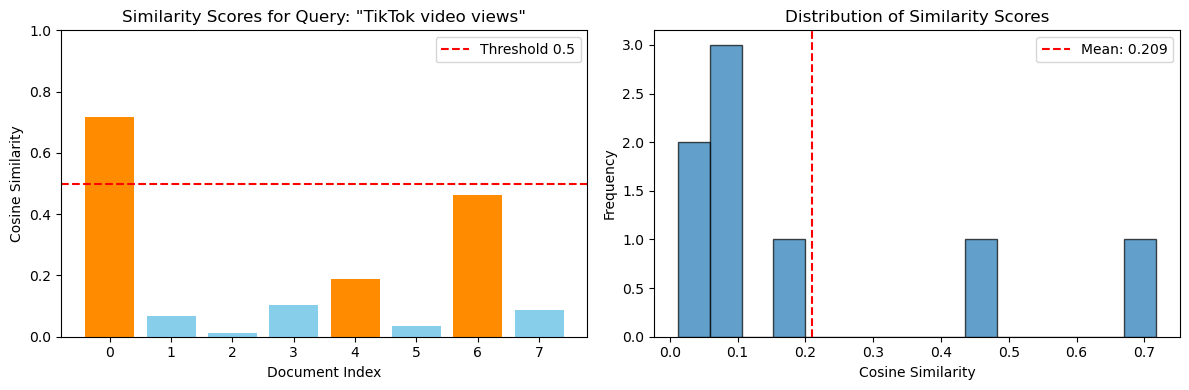


📊 Visualization saved as 'retrieval_scores_visualization.png'


In [16]:
# Cell 10: Create a visualization of retrieval scores
import matplotlib.pyplot as plt

# Test with a specific query across all documents
test_query = "TikTok video views"
q_emb = model.encode([test_query])
similarities = cosine_similarity(q_emb, kb_embeddings)[0]

# Plot similarity distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of similarities
axes[0].bar(range(len(similarities)), similarities, color='skyblue')
axes[0].set_xlabel('Document Index')
axes[0].set_ylabel('Cosine Similarity')
axes[0].set_title(f'Similarity Scores for Query: "{test_query}"')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=0.5, color='r', linestyle='--', label='Threshold 0.5')
axes[0].legend()

# Highlight top-3
top3_indices = np.argsort(similarities)[-3:]
axes[0].bar(top3_indices, similarities[top3_indices], color='darkorange')

# Histogram of similarities
axes[1].hist(similarities, bins=15, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Similarity Scores')
axes[1].axvline(x=np.mean(similarities), color='r', linestyle='--', label=f'Mean: {np.mean(similarities):.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('retrieval_scores_visualization.png', dpi=150)
plt.show()

print("\n📊 Visualization saved as 'retrieval_scores_visualization.png'")

In [17]:
# Cell 11: Performance benchmark
import time

print("="*60)
print("⏱️  RETRIEVAL LATENCY BENCHMARK")
print("="*60)

# Test with multiple queries to measure average latency
num_tests = 20
latencies = []

for i in range(num_tests):
    query = f"Test query number {i} about TikTok"
    
    start_time = time.time()
    docs, scores = retrieve(query, k=3)
    latency_ms = (time.time() - start_time) * 1000
    latencies.append(latency_ms)

avg_latency = np.mean(latencies)
p95_latency = np.percentile(latencies, 95)
p99_latency = np.percentile(latencies, 99)

print(f"\n📊 Benchmark results ({num_tests} queries):")
print(f"   Average latency: {avg_latency:.2f} ms")
print(f"   95th percentile: {p95_latency:.2f} ms")
print(f"   99th percentile: {p99_latency:.2f} ms")
print(f"   Min latency: {np.min(latencies):.2f} ms")
print(f"   Max latency: {np.max(latencies):.2f} ms")

# Check if real-time capable (under 100ms is good for production)
if avg_latency < 100:
    print(f"\n✅ System is real-time capable (<100ms average)")
else:
    print(f"\n⚠️  Consider optimizations for production (quantization, better hardware)")

⏱️  RETRIEVAL LATENCY BENCHMARK

📊 Benchmark results (20 queries):
   Average latency: 11.91 ms
   95th percentile: 24.44 ms
   99th percentile: 27.26 ms
   Min latency: 0.00 ms
   Max latency: 27.97 ms

✅ System is real-time capable (<100ms average)


In [ ]:
# Cell 12: Interactive retrieval demo (for you to test manually)
print("="*60)
print("🎮 INTERACTIVE RETRIEVAL DEMO")
print("="*60)
print("Type your questions about ByteDance/TikTok/CapCut/Lark")
print("Type 'exit' to stop\n")

while True:
    user_query = input("🔍 Your question: ").strip()
    
    if user_query.lower() in ['exit', 'quit', 'q']:
        print("👋 Exiting demo...")
        break
    
    if not user_query:
        print("   Please enter a question.\n")
        continue
    
    # Retrieve relevant documents
    docs, scores = retrieve(user_query, k=3)
    
    print(f"\n📄 Top relevant information:")
    for i, (doc, score) in enumerate(zip(docs, scores), 1):
        relevance = "HIGH" if score > 0.6 else "MEDIUM" if score > 0.4 else "LOW"
        print(f"\n   {i}. [Relevance: {relevance} | Score: {score:.3f}]")
        print(f"      {doc[:200]}...")
    
    print("\n" + "-"*40 + "\n")

🎮 INTERACTIVE RETRIEVAL DEMO
Type your questions about ByteDance/TikTok/CapCut/Lark
Type 'exit' to stop



🔍 Your question:  Show me documents comparing TikTok and Douyin features



📄 Top relevant information:

   1. [Relevance: MEDIUM | Score: 0.416]
      The TikTok algorithm prioritizes watch time (60%), completion rate (25%), and engagement (15%). For best results, post when your audience is active (7-9 PM local time)....

   2. [Relevance: LOW | Score: 0.285]
      Untuk hasil terbaik di TikTok Indonesia, posting antara jam 7-9 malam WIB. Gunakan musik lokal dan caption dalam Bahasa Indonesia untuk engagement lebih tinggi....

   3. [Relevance: LOW | Score: 0.210]
      Cara atasi masalah eksport CapCut: Pastikan ruang storan mencukupi, tutup aplikasi lain, dan gunakan format eksport H.264 untuk hasil terbaik....

----------------------------------------



🔍 Your question:  Find documents about ByteDance’s AI research focus.



📄 Top relevant information:

   1. [Relevance: LOW | Score: 0.202]
      ByteDance complies with GDPR, CCPA, and PDPA. User data is encrypted at rest (AES-256) and in transit (TLS 1.3). Data retention is 30 days for inactive accounts....

   2. [Relevance: LOW | Score: 0.175]
      Cara atasi masalah eksport CapCut: Pastikan ruang storan mencukupi, tutup aplikasi lain, dan gunakan format eksport H.264 untuk hasil terbaik....

   3. [Relevance: LOW | Score: 0.171]
      The TikTok algorithm prioritizes watch time (60%), completion rate (25%), and engagement (15%). For best results, post when your audience is active (7-9 PM local time)....

----------------------------------------



🔍 Your question:  Show me comparisons of Lark vs Slack.



📄 Top relevant information:

   1. [Relevance: LOW | Score: 0.341]
      Lark supports SSO integration, audit logs, and role-based access control. Admins can configure security policies in Admin Console > Security Settings....

   2. [Relevance: LOW | Score: 0.196]
      The TikTok algorithm prioritizes watch time (60%), completion rate (25%), and engagement (15%). For best results, post when your audience is active (7-9 PM local time)....

   3. [Relevance: LOW | Score: 0.092]
      Untuk hasil terbaik di TikTok Indonesia, posting antara jam 7-9 malam WIB. Gunakan musik lokal dan caption dalam Bahasa Indonesia untuk engagement lebih tinggi....

----------------------------------------



🔍 Your question:  Locate tutorials on adding captions in CapCut.



📄 Top relevant information:

   1. [Relevance: LOW | Score: 0.313]
      CapCut login issues: Clear cache (Settings > Apps > CapCut > Clear Cache), update to latest version, check internet connection, or use 'Forgot Password' feature....

   2. [Relevance: LOW | Score: 0.224]
      Cara atasi masalah eksport CapCut: Pastikan ruang storan mencukupi, tutup aplikasi lain, dan gunakan format eksport H.264 untuk hasil terbaik....

   3. [Relevance: LOW | Score: 0.083]
      Untuk hasil terbaik di TikTok Indonesia, posting antara jam 7-9 malam WIB. Gunakan musik lokal dan caption dalam Bahasa Indonesia untuk engagement lebih tinggi....

----------------------------------------

